/tmp/ipython-input-1629846330.py:18: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download("^FTSE", period="10d", interval="5m")
[*********************100%***********************]  1 of 1 completed



📊 === Linear Regression ===
Accuracy  : 57.58%
Precision : 0.552
Recall    : 0.564
F1-Score  : 0.558
MAE       : 3.945
Confusion Matrix:
 [[61 43]
 [41 53]]

📊 === Support Vector Regressor (SVR) ===
Accuracy  : 55.56%
Precision : 0.531
Recall    : 0.543
F1-Score  : 0.537
MAE       : 8.962
Confusion Matrix:
 [[59 45]
 [43 51]]

📊 === Random Forest Regressor ===
Accuracy  : 56.06%
Precision : 0.538
Recall    : 0.521
F1-Score  : 0.530
MAE       : 4.894
Confusion Matrix:
 [[62 42]
 [45 49]]


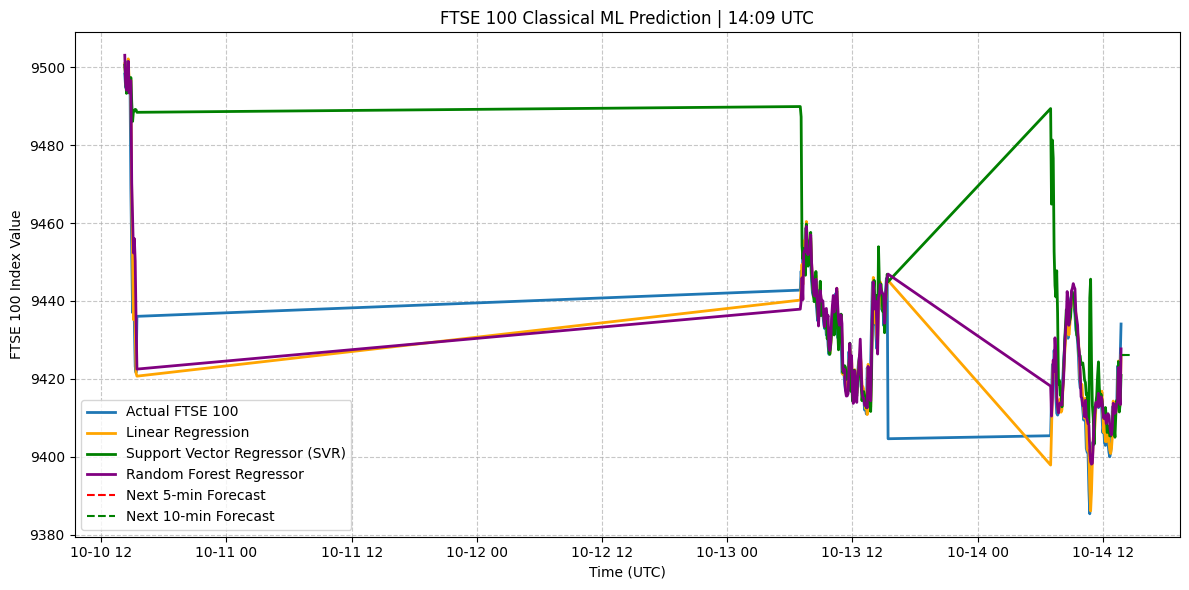

In [ ]:
# === Classical ML Models for FTSE 100 Price Prediction (Continuous Graph) ===
!pip install yfinance scikit-learn matplotlib --quiet

import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime, timedelta, timezone
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, mean_absolute_error, confusion_matrix

# -------------------------------
# 1️⃣ Fetch FTSE 100 Historical Data
# -------------------------------
data = yf.download("^FTSE", period="10d", interval="5m")
data.dropna(inplace=True)

# Feature Engineering
data['Returns'] = data['Close'].pct_change()
data['SMA_10'] = data['Close'].rolling(window=10).mean()
data['EMA_10'] = data['Close'].ewm(span=10, adjust=False).mean()
data['Volatility'] = data['Close'].rolling(window=10).std()
data['Momentum'] = data['Close'] / data['Close'].shift(5) - 1
data.dropna(inplace=True)

# Target: Next close price
data['Target'] = data['Close'].shift(-1)
data.dropna(inplace=True)

features = ['Open', 'High', 'Low', 'Close', 'Volume', 'Returns', 'SMA_10', 'EMA_10', 'Volatility', 'Momentum']
X = data[features].values
y = data['Target'].values.reshape(-1, 1)

# -------------------------------
# 2️⃣ Preprocessing
# -------------------------------
scaler_X = StandardScaler()
scaler_y = StandardScaler()
X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y)

split = int(0.8 * len(X_scaled))
X_train, X_test = X_scaled[:split], X_scaled[split:]
y_train, y_test = y_scaled[:split], y_scaled[split:]
timestamps = data.index[split:]

# -------------------------------
# 3️⃣ Classical Regressor Models
# -------------------------------
models = {
    "Linear Regression": LinearRegression(),
    "Support Vector Regressor (SVR)": SVR(kernel='rbf', C=10, epsilon=0.01),
    "Random Forest Regressor": RandomForestRegressor(n_estimators=200, random_state=42)
}

results = {}

for name, reg in models.items():
    reg.fit(X_train, y_train.ravel())
    y_pred_scaled = reg.predict(X_test).reshape(-1, 1)
    y_pred_inv = scaler_y.inverse_transform(y_pred_scaled)
    y_true_inv = scaler_y.inverse_transform(y_test)

    # Compute directional metrics
    y_pred_dir = np.sign(np.diff(y_pred_inv, axis=0))
    y_true_dir = np.sign(np.diff(y_true_inv, axis=0))
    acc = accuracy_score(y_true_dir > 0, y_pred_dir > 0)
    prec = precision_score(y_true_dir > 0, y_pred_dir > 0, zero_division=0)
    rec = recall_score(y_true_dir > 0, y_pred_dir > 0, zero_division=0)
    f1 = f1_score(y_true_dir > 0, y_pred_dir > 0, zero_division=0)
    mae = mean_absolute_error(y_true_inv, y_pred_inv)
    cm = confusion_matrix(y_true_dir > 0, y_pred_dir > 0)

    results[name] = {
        "Predictions": y_pred_inv.flatten(),
        "Accuracy": acc, "Precision": prec,
        "Recall": rec, "F1": f1, "MAE": mae, "ConfusionMatrix": cm
    }

# -------------------------------
# 4️⃣ Print Metrics
# -------------------------------
for name, metrics in results.items():
    print(f"\n📊 === {name} ===")
    print(f"Accuracy  : {metrics['Accuracy']*100:.2f}%")
    print(f"Precision : {metrics['Precision']:.3f}")
    print(f"Recall    : {metrics['Recall']:.3f}")
    print(f"F1-Score  : {metrics['F1']:.3f}")
    print(f"MAE       : {metrics['MAE']:.3f}")
    print("Confusion Matrix:\n", metrics["ConfusionMatrix"])

# -------------------------------
# 5️⃣ Graph: Actual vs Predicted Prices + 5/10-min Dotted Forecasts
# -------------------------------
plt.figure(figsize=(12,6))
plt.plot(timestamps, scaler_y.inverse_transform(y_test), label='Actual FTSE 100', color='tab:blue', linewidth=2)

colors = ['orange', 'green', 'purple']
for (name, metrics), c in zip(results.items(), colors):
    plt.plot(timestamps, metrics["Predictions"], label=name, color=c, linewidth=2)

# Dotted 5-min and 10-min forecast
last_time = timestamps[-1]
last_pred = list(results.values())[0]["Predictions"][-1]
next5_timestamps = [last_time + timedelta(minutes=5*i) for i in range(1,6)]
next10_timestamps = [last_time + timedelta(minutes=5*i) for i in range(1,11)]
plt.plot(next5_timestamps, [last_pred]*5, 'r--', label='Next 5-min Forecast')
plt.plot(next10_timestamps, [last_pred]*10, 'g--', label='Next 10-min Forecast')

plt.title(f"FTSE 100 Classical ML Prediction | {datetime.now(timezone.utc).strftime('%H:%M UTC')}")
plt.xlabel("Time (UTC)")
plt.ylabel("FTSE 100 Index Value")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()


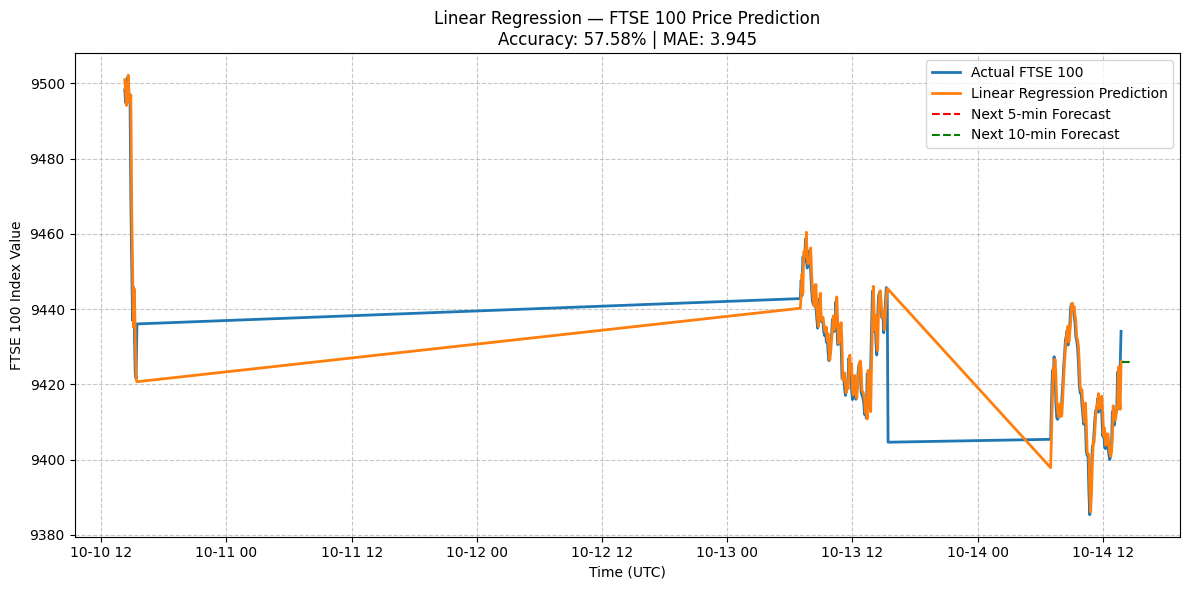

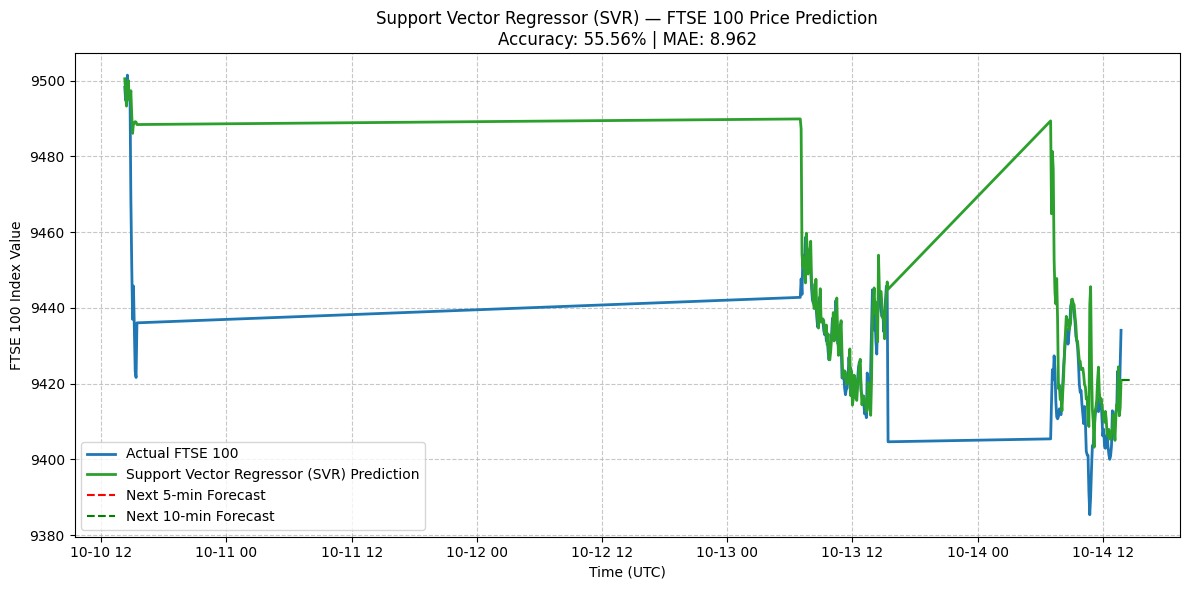

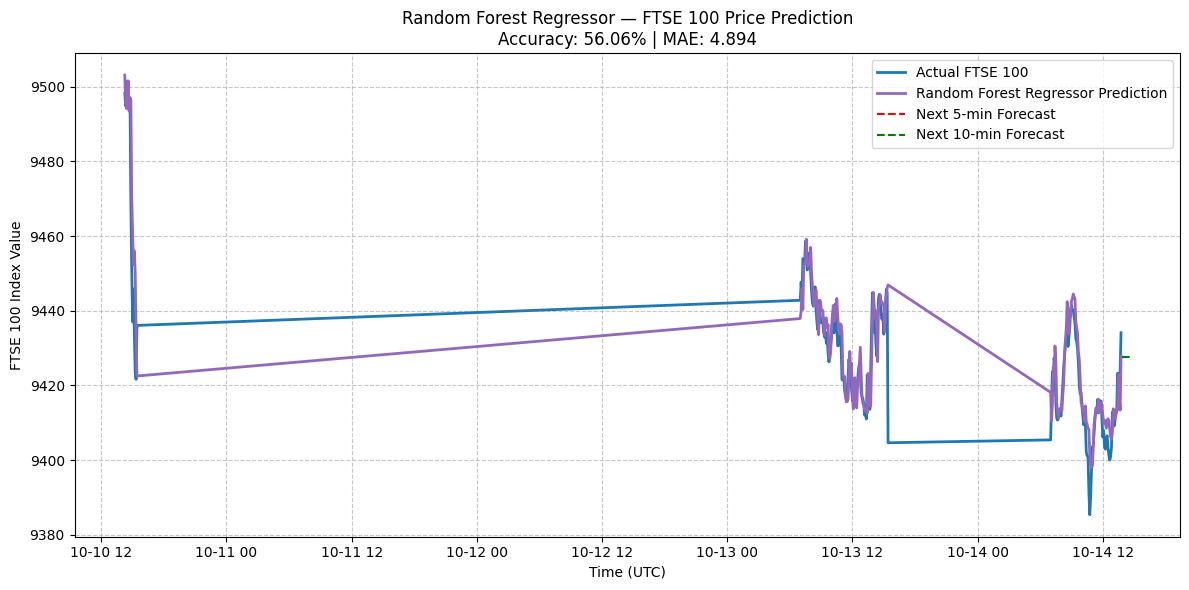

In [ ]:
# === Individual Classical ML Graphs (Distinct Colors + Metrics) ===

from datetime import timezone
import matplotlib.pyplot as plt

# Ground truth prices
actual_prices = scaler_y.inverse_transform(y_test)
timestamps = data.index[split:]

# Custom color palette for each model
model_colors = {
    "Linear Regression": "tab:orange",
    "Support Vector Regressor (SVR)": "tab:green",
    "Random Forest Regressor": "tab:purple"
}

for name, metrics in results.items():
    # --- Create new figure for each model ---
    plt.figure(figsize=(12,6))

    # Actual FTSE (blue)
    plt.plot(timestamps, actual_prices, label='Actual FTSE 100', color='tab:blue', linewidth=2)

    # Predicted in unique color
    plt.plot(
        timestamps,
        metrics["Predictions"],
        label=f'{name} Prediction',
        color=model_colors.get(name, 'tab:gray'),
        linewidth=2
    )

    # --- Dotted 5-min and 10-min forecast ---
    last_time = timestamps[-1]
    last_pred = metrics["Predictions"][-1]
    next5_timestamps = [last_time + timedelta(minutes=5*i) for i in range(1,6)]
    next10_timestamps = [last_time + timedelta(minutes=5*i) for i in range(1,11)]
    plt.plot(next5_timestamps, [last_pred]*5, 'r--', label='Next 5-min Forecast')
    plt.plot(next10_timestamps, [last_pred]*10, 'g--', label='Next 10-min Forecast')

    # --- Title and metrics display ---
    acc = metrics["Accuracy"] * 100
    mae = metrics["MAE"]
    plt.title(f"{name} — FTSE 100 Price Prediction\nAccuracy: {acc:.2f}% | MAE: {mae:.3f}")
    plt.xlabel("Time (UTC)")
    plt.ylabel("FTSE 100 Index Value")
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.7)
    plt.tight_layout()
    plt.show()
